# More Volatile Than Ever? 🎢
### A century of the US stock market against the most repeated sentence in financial news

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![More volatile than ever?: Busted](https://img.shields.io/badge/More_volatile_than_ever%3F-Busted-8b949e?style=flat-square)

"Markets have never been this volatile." It has been said about program trading, day traders,
high-frequency algorithms, ETFs and Reddit. We put **ninety-one complete years** of the US market
on the bench, plus thirty years of daily S&P 500 data, and asked whether volatility is actually
rising, whether crash days are getting more common — and if not, why it feels that way.

> 📓 **This is the plain-language layer.** The trend tests, the fixed-b inference and the
> forecast race in full are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is computed from frozen, fingerprinted tapes
> (as-of 2021-12-31); the one synthetic section is labelled as such.

In [1]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from volhistory import data, strategy as st
print("tapes available:", data.have_real(), "| study as-of", data.AS_OF)

tapes available: True | study as-of 2021-12-31


## 0 · The answer first

| Question | Answer (real tape) |
|---|---|
| Is market volatility trending up over a century? | **No.** -5.6% per decade — slightly *down*, and not reliably either way. |
| Was the decade you remember unusually wild? | The 1930s were **2.2×** as volatile as 2008-2017. |
| Are crash days getting more frequent? | They come in bursts (2008-09, 2020), not on a slope. |
| Then why does it feel that way? | Headlines quote **points**. Point moves grow **+95% per decade**; percent moves **+4%**. |
| What should a risk manager do? | Mix recent and long-run volatility — don't extrapolate a rise. |

**Signal: None · Tradability: Fragile · More volatile than ever? Busted.**

## 1 · The claim

The strong version, stated fairly: markets today are wired differently. Algorithms trade in
microseconds and pull liquidity at the first sign of stress; ETFs let a whole market be sold in
one click; social media turns a rumour into a stampede in minutes. Every one of those changes
plausibly *amplifies* moves. So volatility should be higher than in the slow, human markets of
the past — and the extreme days, the 1987s and 2020s, should be getting more common.

It is a serious argument. The 2010 flash crash really did happen in minutes, and studies of
ETF ownership do find it raises the volatility of individual stocks.

## 2 · So what?

If it were true, every risk number calibrated on history would be too low, and should be scaled
up by an amount that grows each year. Pension funds, banks and anyone sizing a position on
"normal" volatility would be systematically under-protected. If it is false, the people
extrapolating it are paying for insurance they do not need — and, worse, are forecasting the
wrong thing.

## 3 · How we'd know

Decided before looking:

- **A trend** in volatility means a slope in log volatility year after year that survives tests
  which know volatility is *sticky* (a calm year is usually followed by a calm year — that
  stickiness fools naive trend lines).
- **More extreme days** means the count of 3σ days per year trends up, by a test that knows
  crashes arrive in clusters.
- **"Mirage"** would be: no tape shows a significant rise, the trend-extrapolating forecast does
  no better than the long-run average, and the feeling is explained by something else.

> 🔬 **For the quants.** The bar is a positive slope with Newey-West *t* ≥ 2 *and* a
> Kiefer-Vogelsang-Bunzel fixed-b p < 0.05 (critical value 5.91, simulated), plus a
> residual block bootstrap. The rule is `strategy.verdict`.

## 4 · The teardown

### 4.1 · Ninety-one years of volatility

In [2]:
m = data.load_monthly()      # Fama-French monthly, TOTAL return, 1926-07 -> 2018-11
d = data.load_daily()        # S&P 500 daily, PRICE index, 1990 -> 2021 (partial 2022 dropped)
o = data.load_ohlc()         # S&P 500 daily OHLC, PRICE index, 1999 -> 2018
for p in data.provenance():
    print(f"{p['tape']:8s} {p['label']:55s} {p['first']} -> {p['last']}  fp {p['fingerprint']}")
rv_c = st.annual_rv_from_monthly(m, data.FIRST_FULL_YEAR_MONTHLY, data.LAST_FULL_YEAR_MONTHLY)
rv_d = st.annual_rv_from_daily(d)
rv_p = st.annual_rv_parkinson(o)

monthly  Fama-French Mkt-RF + RF, monthly, TOTAL return          1926-07-31 -> 2018-11-30  fp 5bf075a78851
daily    S&P 500 index level, daily, PRICE index (no dividends)  1990-01-02 -> 2021-12-31  fp 6801b52cecb2
ohlc     S&P 500 Open/High/Low/Close, daily, PRICE index         1999-01-04 -> 2018-12-31  fp 317bd3262050


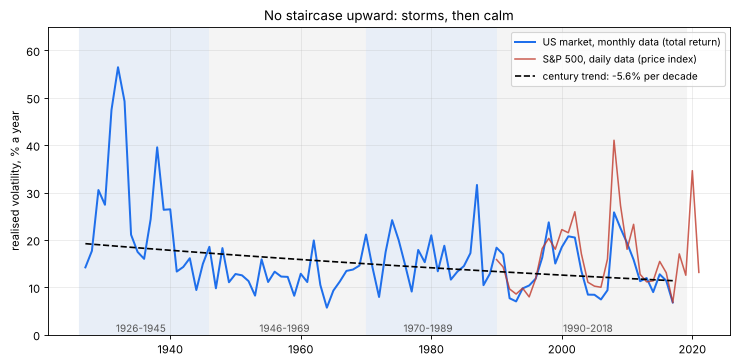

century trend -5.6%/decade, Newey-West t -2.13, fixed-b p 0.26


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
for (name, y0, y1), c in zip(data.ERAS, ["#e8eef7", "#f4f4f4", "#e8eef7", "#f4f4f4"]):
    ax.axvspan(y0, y1 + 0.99, color=c, zorder=0)
    ax.text((y0 + y1) / 2, 0.62, name, ha="center", fontsize=9, color="#555")
ax.plot(rv_c.index, rv_c * 100, color="#1f6feb", lw=1.8, label="US market, monthly data (total return)")
ax.plot(rv_d.index, rv_d * 100, color="#c0392b", lw=1.4, alpha=0.8, label="S&P 500, daily data (price index)")
tr = st.trend_test(np.log(rv_c), n_boot=499)
yrs = np.array(rv_c.index, dtype=float)
fit = np.exp(np.polyval(np.polyfit(yrs, np.log(rv_c), 1), yrs))
ax.plot(yrs, fit * 100, "k--", lw=1.5, label=f"century trend: {tr['pct_per_decade']:+.1%} per decade")
ax.set_ylabel("realised volatility, % a year"); ax.set_ylim(0, 65)
ax.legend(loc="upper right", fontsize=9)
ax.set_title("No staircase upward: storms, then calm")
plt.show()
print(f"century trend {tr['pct_per_decade']:+.1%}/decade, Newey-West t {tr['t_nw']:+.2f}, "
      f"fixed-b p {tr['p_kvb']:.2f}")

The tallest spikes are in the **1930s**. The post-war decades were calm, the 1970s and 1987 woke
things up, and then 2000-02, 2008 and 2020 each spiked — and each calmed down. If you drew the
line from 1995 to 2008 you would see a terrifying rise; from 1932 to 2017, a decline. Neither is a
trend.

### 4.2 · The decade you remember vs the 1930s

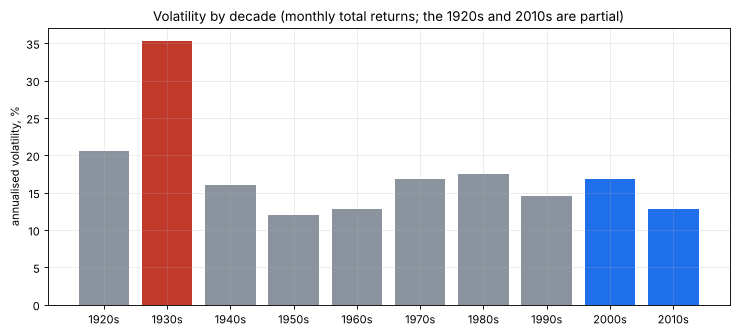

1930-39: 35.3%   2008-17: 15.8%   ratio 2.2x
months the market fell 10% or more: 15 vs 2


In [4]:
dc = st.decade_contrast(m, (1930, 1939), (2008, 2017))
dv = st.decade_vols(m)
fig, ax = plt.subplots(figsize=(11, 4.5))
cols = ["#c0392b" if i == "1930s" else "#1f6feb" if i in ("2000s", "2010s") else "#8b949e" for i in dv.index]
ax.bar(dv.index, dv["vol"] * 100, color=cols)
ax.set_ylabel("annualised volatility, %")
ax.set_title("Volatility by decade (monthly total returns; the 1920s and 2010s are partial)")
plt.show()
print(f"1930-39: {dc['vol_a']:.1%}   2008-17: {dc['vol_b']:.1%}   ratio {dc['ratio']:.1f}x")
print(f"months the market fell 10% or more: {dc['n_down10_a']} vs {dc['n_down10_b']}")

The ten years that contain the 2008 crisis — the most frightening stretch most readers have
lived through — were **less than half** as volatile as the 1930s, which had
**15 months** with a fall of 10% or more against 2. Memory
is a bad yardstick: we compare today with the last thing we remember, not with the record.

### 4.3 · Why it *feels* more volatile: points versus percent

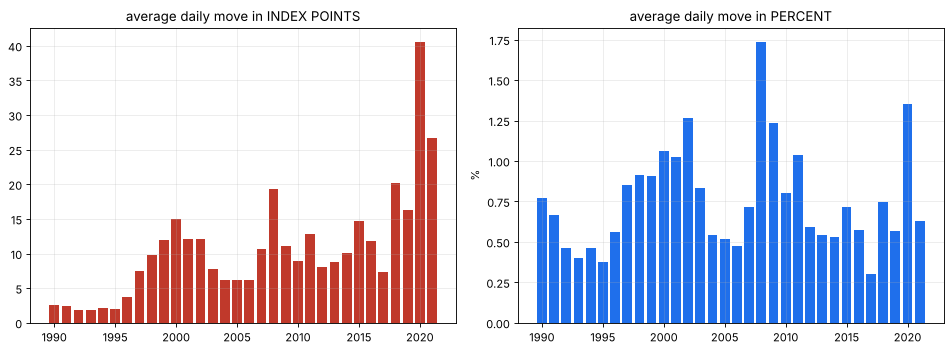

points: +95% per decade;  percent: +4% per decade
of the 20 biggest POINT drops, 95% are in 2012-2021; of the 20 biggest PERCENT drops, 25%


In [5]:
pp = st.points_vs_percent(d)
y = pp["yearly"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(y.index, y["mean_abs_points"], color="#c0392b")
axes[0].set_title("average daily move in INDEX POINTS")
axes[1].bar(y.index, y["mean_abs_pct"] * 100, color="#1f6feb")
axes[1].set_title("average daily move in PERCENT")
axes[1].set_ylabel("%")
plt.tight_layout(); plt.show()
print(f"points: {pp['trend_points']['pct_per_decade']:+.0%} per decade;  "
      f"percent: {pp['trend_pct']['pct_per_decade']:+.0%} per decade")
print(f"of the 20 biggest POINT drops, {pp['top_points_share_last_decade']:.0%} are in "
      f"{pp['last_decade_start']}-2021; of the 20 biggest PERCENT drops, "
      f"{pp['top_pct_share_last_decade']:.0%}")

This is the whole trick. A 2% day when the S&P is at 400 is 8 points; at 4,000 it is 80. The
*risk* is identical. The *headline* — "biggest point drop in history" — is ten times bigger. An
index that grows sets point records automatically, and the S&P 500 grew about tenfold over this
tape. Every "record crash" story you have read since 2018 is, first, a statement about how high
the market had climbed.

> 🔬 **For the quants.** ΔP = P × r, so the trend in log|ΔP| is the trend in log P plus
> the trend in log|r|. The first is enormous, the second is nil.

### 4.4 · Are extreme days getting more frequent?

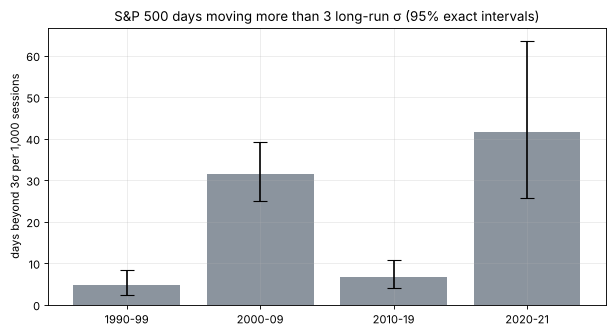

         days  count    rate   ci_lo   ci_hi
bucket                                      
1990-99  2527     12  4.7000  2.5000  8.3000
2000-09  2515     79 31.4000 24.9000 39.1000
2010-19  2516     17  6.8000  3.9000 10.8000
2020-21   505     21 41.6000 25.7000 63.6000


In [6]:
lr = st.log_returns_from_price(d)
B = (("1990-99", 1990, 1999), ("2000-09", 2000, 2009), ("2010-19", 2010, 2019), ("2020-21", 2020, 2021))
tab = st.count_table(st.extreme_days(lr, 3.0, "fixed"), B)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(tab.index, tab["rate"], color="#8b949e",
       yerr=[tab["rate"] - tab["ci_lo"], tab["ci_hi"] - tab["rate"]], capsize=6)
ax.set_ylabel("days beyond 3σ per 1,000 sessions")
ax.set_title("S&P 500 days moving more than 3 long-run σ (95% exact intervals)")
plt.show()
print(tab.round(1).to_string())

The 2000s are high because of 2008-09; 2020-21 is high because of March 2020 (and is only two
years, hence the huge interval). The 2010s were *quieter* than the 2000s. That is two bursts, not
a slope — and once the test is told that crash days come in clusters, the apparent trend is
indistinguishable from chance (p = 0.58).

## 5 · The verdict

**Signal: None.** No tape shows a significant rise in volatility: the century trend is
-5.6% per decade, the daily 1990-2021 tape +6.5% with *t* = +0.70.

**Tradability: Fragile.** A rule that extrapolates the rise is a poor risk forecast; where it
seems to help, the help comes from forgetting the 1930s, not from the trend.

**More volatile than ever? Busted.** The 1930s were 2.2× as volatile as
2008-2017.

> **In one sentence:** A century of US market volatility shows no upward trend (-5.6% per decade, KVB p = 0.26), the 1930s were 2.2× as volatile as 2008-2017, and the record crashes in the headlines are point moves that grow with the index (+95% per decade in points vs +4% in percent) — a risk manager should mix recent and long-run volatility, not extrapolate a rise.

## 6 · Could you use it?

The useful version of the question is a risk manager's: *what volatility should I plan for next
year?* We ran a race, out of sample, between the **long-run average**, **recent history**, and
**the trend extrapolated** — the claim turned into a rule.

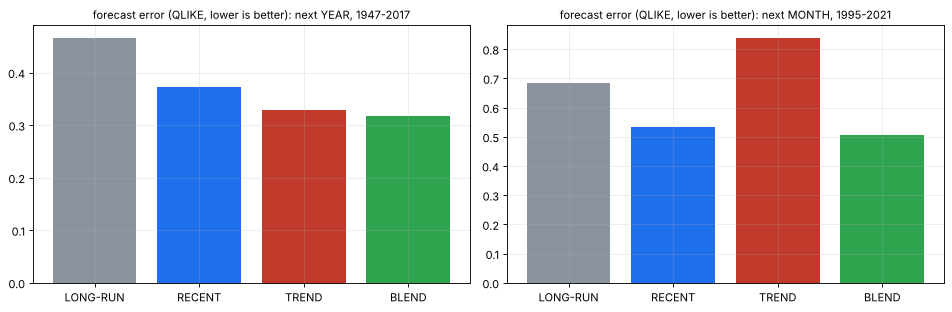

In [7]:
fa = st.forecast_race(rv_c ** 2, recent=1, trend_window=20, burn=20)
fm = st.forecast_race(st.monthly_rv_from_daily(d), recent=12, trend_window=60, burn=60)
order = ["LONG-RUN", "RECENT", "TREND", "BLEND"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, f, title in ((axes[0], fa, "next YEAR, 1947-2017"), (axes[1], fm, "next MONTH, 1995-2021")):
    q = [f["mean_qlike"][k] for k in order]
    ax.bar(order, q, color=["#8b949e", "#1f6feb", "#c0392b", "#2ea44f"])
    ax.set_title(f"forecast error (QLIKE, lower is better): {title}", fontsize=10)
plt.tight_layout(); plt.show()

Recent history helps, because volatility is sticky in the short run. The long-run average helps,
because storms end. The best forecast in both races **mixes** them (green). The trend rule is the
worst forecast month-to-month, and its apparent edge year-to-year disappears against a plain
20-year average with no slope at all. There is nothing to trade here; there is a calibration
mistake to avoid.

## 7 · Going further 🚪

- **Individual stocks are a different story.** Campbell, Lettau, Malkiel & Xu (2001) found
  *idiosyncratic* volatility rising through the 1990s while market volatility did not. A fork
  with a stock panel could ask whether that trend survived.
- **Intraday is a different story too.** Flash crashes are minutes long; daily and monthly data
  cannot see them. A fork with intraday data could test whether *within-day* extremes rose
  after 2010.
- **Other countries.** The US had the calmest century of any major market; the claim deserves a
  test on markets that did not.
- **Challenge us:** change the eras, the start year or the forecast window in
  `examples/verify.py` and see whether anything flips.